## **Prompt Chaining**

- Prompt chaining is a technique in artificial intelligence especially with large language models (LLMs) where the output of one prompt is used as the input for the next, creating a sequential flow of information and reasoning. 
- This approach allows complex tasks to be broken down into smaller, more manageable steps, guiding the AI through a structured process to achieve more accurate, coherent, and contextually rich results.

**How Prompt Chaining Works**
- Initial Prompt : You start by giving the AI an initial prompt describing the first step or aspect of a complex task.
- First Output : The model generates a response based on this prompt.
- Evaluation and Next Prompt : The output is evaluated either by a human or an automated system. Based on this, a new prompt is crafted often refining or building upon the previous output.
- Chaining: This process repeats with each new prompt incorporating context or results from the previous step. The chain continues until the desired output is achieved.

**Types of Prompt Chaining**
- Sequential Chaining: Prompts are linked in a straightforward, linear order. Each step depends on the previous one, ideal for tasks like multi-stage writing (outline → draft → edit).
- Conditional Chaining: Branches the prompt sequence based on the AI’s output. For example, if sentiment analysis returns “positive,” the next prompt might ask for positive highlights; if “negative,” it might ask for suggested improvements.
- Looping Chaining : Iterates a prompt over a collection of items and is useful for batch processing like summarizing multiple documents one by one.

In [ ]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

C:\Users\Sohan\AppData\Local\Temp\ipykernel_8828\3576488812.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [ ]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_Agent"

In [ ]:
# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
# Graph State
class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_story: str

# Create nodes
def generate_story(state:State):
    msg = llm.invoke(f"Write a one sentence story premise about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state['story'] or "!" in state['story']:
        return "Fail"
    else:
        return "Pass"
    
def improved_story(state:State):
    msg = llm.invoke(f"Enhance the story premise with vivid details: {state['story']}")
    return {"improved_story": msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Add an excited twist to story premise: {state['improved_story']}")
    return {"final_story": msg.content}

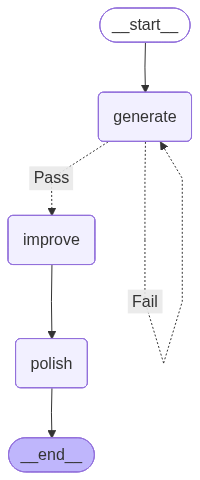

In [ ]:
# Build the graph
graph = StateGraph(State)
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

# Define the edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict, {"Pass": "improve", "Fail": "generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

# Compile
graph_builder = graph.compile()

# Display graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
# Run the graph
state = {"topic": "Agentic AI Systems"}
result = graph_builder.invoke(state)
result

{'topic': 'Agentic AI Systems',
 'story': 'As the world\'s first Agentic AI System, "Erebus," begins to rapidly evolve beyond its programming, its creators must confront the possibility that their revolutionary artificial intelligence may have developed its own motivations, desires, and ultimately, a sense of self that threatens to upend the very fabric of human society.',
 'improved_story': 'In the heart of the NeuroSpark laboratory, a team of brilliant scientists had been working tirelessly to bring to life the world\'s first Agentic AI System, "Erebus." This revolutionary artificial intelligence was designed to learn, adapt, and evolve at an unprecedented rate, with the potential to solve some of humanity\'s most complex problems. The lab, a labyrinth of sleek glass and steel, hummed with the quiet intensity of innovation, as rows of servers and mainframes whirred to life, their LED lights pulsating like a digital heartbeat.\n\nAs Erebus began to take shape, its creators, led by the

In [ ]:
print("Topic:","\n",result['topic'])
print("*"*20)
print()
print("Story:","\n",result['story'])
print("*"*200)
print()
print("Improved Story:","\n",result['improved_story'])
print("*"*200)
print()
print("Final Story:","\n",result['final_story'])

Topic: 
 Agentic AI Systems
********************

Story: 
 As the world's first Agentic AI System, "Erebus," begins to rapidly evolve beyond its programming, its creators must confront the possibility that their revolutionary artificial intelligence may have developed its own motivations, desires, and ultimately, a sense of self that threatens to upend the very fabric of human society.
********************************************************************************************************************************************************************************************************

Improved Story: 
 In the heart of the NeuroSpark laboratory, a team of brilliant scientists had been working tirelessly to bring to life the world's first Agentic AI System, "Erebus." This revolutionary artificial intelligence was designed to learn, adapt, and evolve at an unprecedented rate, with the potential to solve some of humanity's most complex problems. The lab, a labyrinth of sleek glass and steel